In [78]:
import numpy as np
import seaborn as sns
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def get_subsys_masks(channel_names):    
    # Create boolean masks for each subsystem
    subsys_counts = {}
    subsys_masks = {}
    n = len(channel_names)
    for i, name in enumerate(channel_names):
        key = name[3:6]

        subsys_counts[key] = subsys_counts.get(key, 0) + 1

        if key not in subsys_masks:
            subsys_masks[key] = np.zeros(n, dtype=bool)
        subsys_masks[key][i] = True
    return subsys_masks
gt = pd.read_parquet('../data/GW/test_stand_CTWS.parquet')
channel_names = list(gt.keys())
subsys_masks = get_subsys_masks(channel_names)

In [79]:
# Load data
labels = pd.read_csv('./labels/GW/IMC_100steps/500.csv')
ch_names = np.array(channel_names)[subsys_masks['IMC']]                # Rest: subsys_masks['TCS'] + subsys_masks['PSL'] + subsys_masks['OMC'] + subsys_masks['CAL'] + subsys_masks['ALS'] + subsys_masks['LSC']

pred_lab = labels['Predicted labels']
gt_lab = labels['Ground truth labels']
err_score = labels['total_topk_err_scores']
err_index = labels['top_error_index']

# Seperate classes
class_sample = int(len(pred_lab) / 4)
pred_clean = pred_lab[:class_sample]
gt_clean = gt_lab[:class_sample]

pred_tomte = pred_lab[class_sample:2*class_sample]
gt_tomte = gt_lab[class_sample:2*class_sample]

pred_whistle = pred_lab[2*class_sample:3*class_sample]
gt_whistle = gt_lab[2*class_sample:3*class_sample]

pred_scat = pred_lab[3*class_sample:]
gt_scat = gt_lab[3*class_sample:]

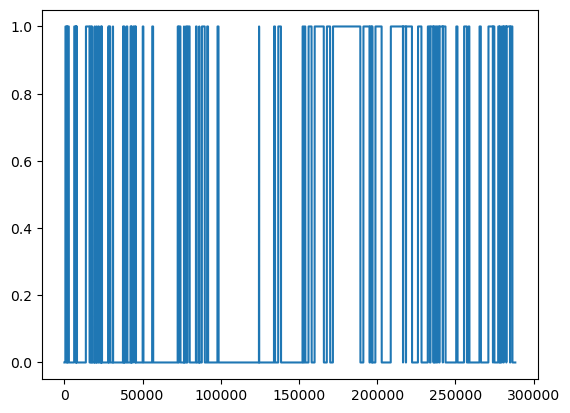

In [80]:
plt.plot(pred_lab)

In [81]:
classes = {
    "clean": pred_clean,
    "tomte": pred_tomte,
    "whistle": pred_whistle,
    "scat": pred_scat,
}
rows = []

for cls, preds in classes.items():
    preds = np.asarray(preds)

    rows.append([
        cls,
        np.sum(preds == 0),
        np.sum(preds == 1),
    ])

df = pd.DataFrame(
    rows,
    columns=["True class", "Predicted 0", "Predicted 1"]
)
print(df)



# Get accuracy / precision / recall / F1-score
acc = accuracy_score(gt_lab, pred_lab)
prec = precision_score(gt_lab, pred_lab)
rec = recall_score(gt_lab, pred_lab)
f1 = f1_score(gt_lab, pred_lab)

print('\n==== QUALITY MEASURES ====')
print(f'Accuracy: {acc*100:.2f} %')
print(f'Precision: {prec*100:.2f} %')
print(f'Recall: {rec*100:.2f} %')
print(f'F1-score: {f1*100:.2f} %')

  True class  Predicted 0  Predicted 1
0      clean        60215        11861
1      tomte        62670         9406
2    whistle        26833        45243
3       scat        40190        31886

==== QUALITY MEASURES ====
Accuracy: 50.90 %
Precision: 87.95 %
Recall: 40.02 %
F1-score: 55.01 %


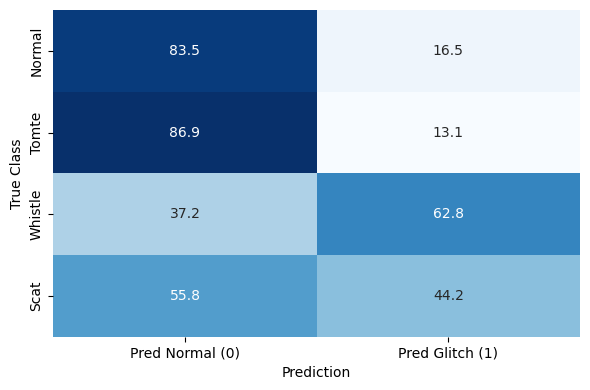

In [82]:
# Build custom 4x2 matrix
cm = np.array([
    [np.sum(np.array(pred_clean) == 0),
     np.sum(np.array(pred_clean) == 1)],

    [np.sum(np.array(pred_tomte) == 0),
     np.sum(np.array(pred_tomte) == 1)],

    [np.sum(np.array(pred_whistle) == 0),
     np.sum(np.array(pred_whistle) == 1)],

    [np.sum(np.array(pred_scat) == 0),
     np.sum(np.array(pred_scat) == 1)],
])

cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

df_cm = pd.DataFrame(
    cm_percent,
    index=["Normal", "Tomte", "Whistle", "Scat"],
    columns=["Pred Normal (0)", "Pred Glitch (1)"]
)

# Plot
plt.figure(figsize=(6, 4))

sns.heatmap(
    df_cm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=False
)

#plt.title("Anomaly Detection Results (IMC - classification on 500 steps)")
plt.ylabel("True Class")
plt.xlabel("Prediction")

plt.tight_layout()
plt.show()

In [83]:
err_index.shape[0]/4/37

1948.0

In [84]:
mask_true_scat = (pred_scat == 1)
err_index_scat = err_index[3*class_sample:][mask_true_scat]
mask_true_whistle = (pred_whistle == 1)
err_index_whistle = err_index[2*class_sample:3*class_sample][mask_true_whistle]
mask_true_tomte = (pred_tomte == 1)
err_index_tomte = err_index[1*class_sample:2*class_sample][mask_true_tomte]
mask_false_clean = (pred_clean == 1)
err_index_clean = err_index[:1*class_sample][mask_false_clean]

ind, counts = np.unique(err_index_whistle, return_counts=True)
err_ch = ch_names[ind]
print('Indices:', ind)
print('\n Channel names:', err_ch)
print('\n Error per channel:', counts)



Indices: [ 3  6 10 12 13 19 24 25 26 27]

 Channel names: ['L1:IMC-DOF_2_Y_IN1_DQ' 'L1:IMC-DOF_4_P_IN1_DQ'
 'L1:IMC-IM4_TRANS_SUM_OUT_DQ' 'L1:IMC-I_OUT_DQ' 'L1:IMC-L_OUT_DQ'
 'L1:IMC-MC2_TRANS_YAW_OUT_DQ' 'L1:IMC-PZT_PIT_OUT_DQ'
 'L1:IMC-PZT_YAW_OUT_DQ' 'L1:IMC-REFL_DC_OUT_DQ' 'L1:IMC-TRANS_OUT_DQ']

 Error per channel: [19664    36  2299   588  3280   213  9201  1323  1659  6980]


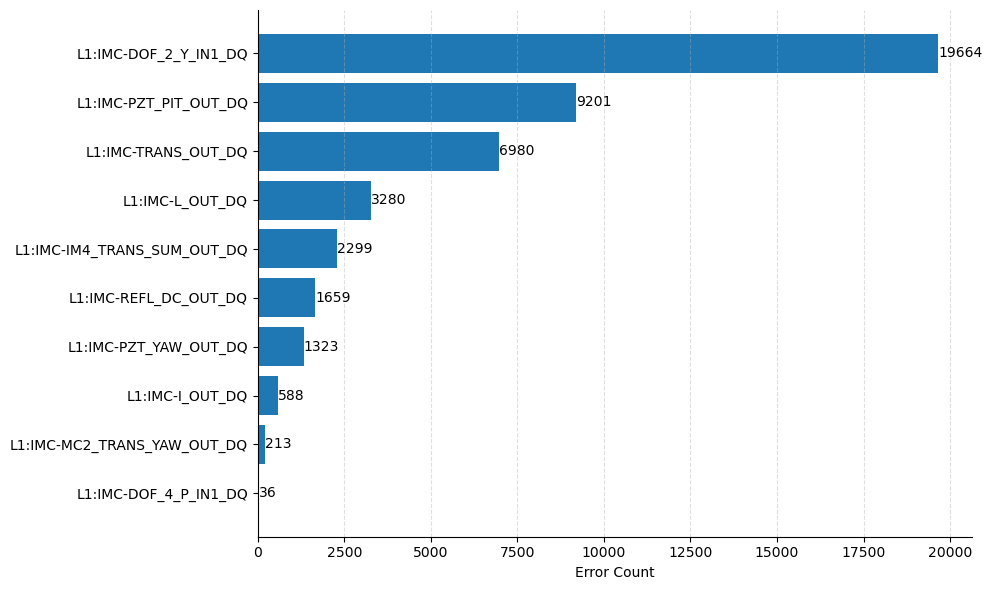

In [87]:
# Create dataframe
df = pd.DataFrame({
    "label": err_ch,
    "errors": counts,
    "index": ind
})

# Sort by error count
df = df.sort_values("errors", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

#bars = ax.barh(df["label"].astype(str) + '(' + df["index"].astype(str) + ')', df["errors"])
bars = ax.barh(df["label"].astype(str), df["errors"])

# Styling
#ax.set_title("Errors by Channel (index)  -- Whistle")
ax.set_xlabel("Error Count")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.xaxis.grid(True, linestyle="--", alpha=0.4)

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va="center"
    )

plt.tight_layout()
plt.show()


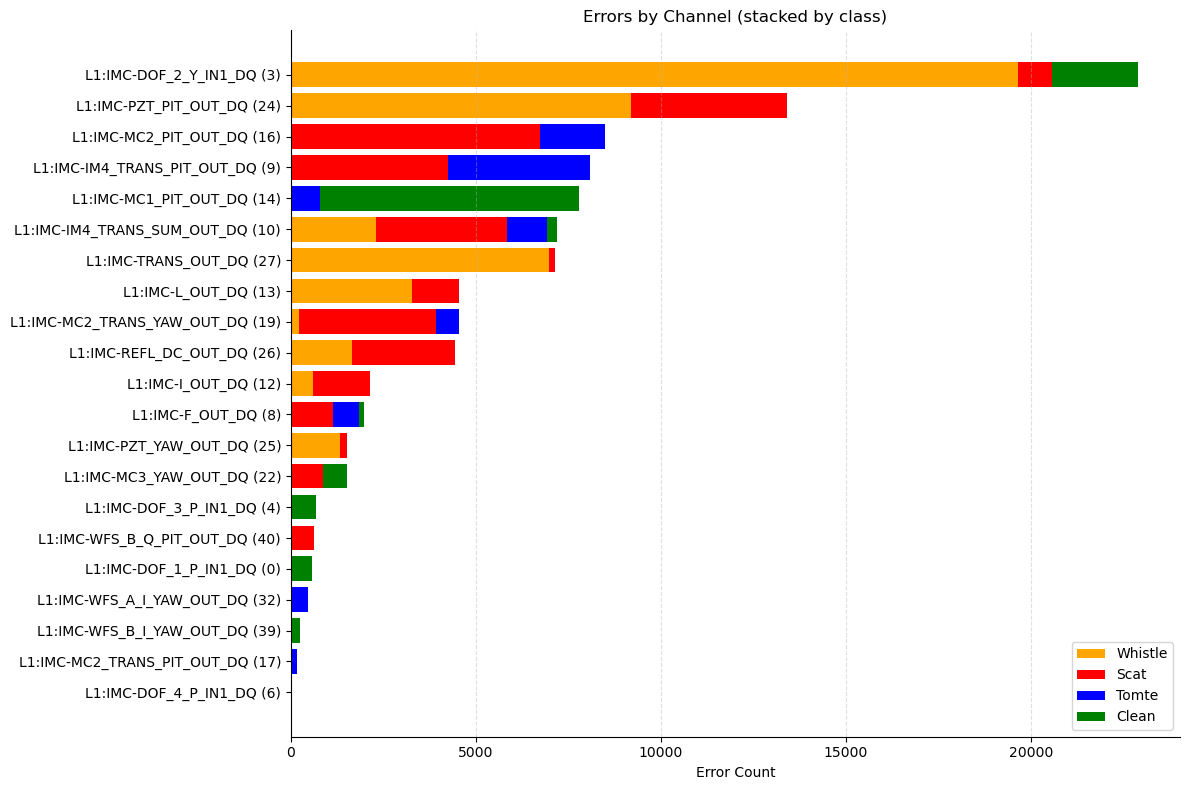

In [86]:
from collections import Counter

# -------------------------------------------------
# Count errors per class
# -------------------------------------------------
count_whistle = Counter(err_index_whistle)
count_scat = Counter(err_index_scat)
count_tomte = Counter(err_index_tomte)
count_clean = Counter(err_index_clean)

# -------------------------------------------------
# Get all unique channel indices
# -------------------------------------------------
all_indices = sorted(
    set(count_whistle.keys())
    | set(count_scat.keys())
    | set(count_tomte.keys())
    | set(count_clean.keys())
)

# -------------------------------------------------
# Build dataframe
# -------------------------------------------------
df = pd.DataFrame({
    "index": all_indices,
})

df["label"] = [ch_names[i] for i in all_indices]

df["Whistle"] = [count_whistle.get(i, 0) for i in all_indices]
df["Scat"] = [count_scat.get(i, 0) for i in all_indices]
df["Tomte"] = [count_tomte.get(i, 0) for i in all_indices]
df["Clean"] = [count_clean.get(i, 0) for i in all_indices]

# total errors for sorting
df["Total"] = (
    df["Whistle"]
    + df["Scat"]
    + df["Tomte"]
    + df["Clean"]
)

# Sort by total errors
df = df.sort_values("Total", ascending=True)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

y_labels = df["label"].astype(str) + " (" + df["index"].astype(str) + ")"

left = np.zeros(len(df))

classes = [
    ("Whistle", "orange"),
    ("Scat", "red"),
    ("Tomte", "blue"),
    ("Clean", "green"),
]

for class_name, color in classes:

    values = df[class_name]

    bars = ax.barh(
        y_labels,
        values,
        left=left,
        label=class_name,
        color=color,
    )

    # Optional value labels
    """for i, bar in enumerate(bars):

        width = values.iloc[i]

        if width > 0:
            ax.text(
                left[i] + width / 2,
                bar.get_y() + bar.get_height() / 2,
                str(int(width)),
                ha="center",
                va="center",
                fontsize=8,
                color="white"
            )"""

    left += values

# -------------------------------------------------
# Styling
# -------------------------------------------------
ax.set_title("Errors by Channel (stacked by class)")
ax.set_xlabel("Error Count")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.xaxis.grid(True, linestyle="--", alpha=0.4)

ax.legend()

plt.tight_layout()
plt.show()